### 1.Import Important Libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

### 2.Load DataSet

In [2]:
df = pd.read_csv('../Data/student_exam_scores.csv')

In [3]:
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


### 3.Understanding the Dataset

In [4]:
df.shape

(200, 6)

In [5]:
df.info

<bound method DataFrame.info of     student_id  hours_studied  ...  previous_scores  exam_score
0         S001            8.0  ...               45        30.2
1         S002            1.3  ...               55        25.0
2         S003            4.0  ...               86        35.8
3         S004            3.5  ...               66        34.0
4         S005            9.1  ...               71        40.3
..         ...            ...  ...              ...         ...
195       S196           10.5  ...               87        42.7
196       S197            7.1  ...               92        40.4
197       S198            1.6  ...               76        28.2
198       S199           12.0  ...               58        42.0
199       S200           10.2  ...               68        37.8

[200 rows x 6 columns]>

In [6]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [7]:
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='str')

### 4.Data Cleaning

In [9]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

In [13]:
df.isna().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

### 5.Create Target Variable

In [15]:
df['pass_fail'] = (df['exam_score']>=30).astype(int)

In [16]:
df.head(3)

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score,pass_fail
0,S001,8.0,8.8,72.1,45,30.2,1
1,S002,1.3,8.6,60.7,55,25.0,0
2,S003,4.0,8.2,73.7,86,35.8,1


In [17]:
df['pass_fail'].value_counts()

pass_fail
1    144
0     56
Name: count, dtype: int64

In [18]:
# showing Pass Fail in Percentage
df['pass_fail'].value_counts(normalize=True)*100

pass_fail
1    72.0
0    28.0
Name: proportion, dtype: float64

### 6.Exploratory Data Analysis (EDA)

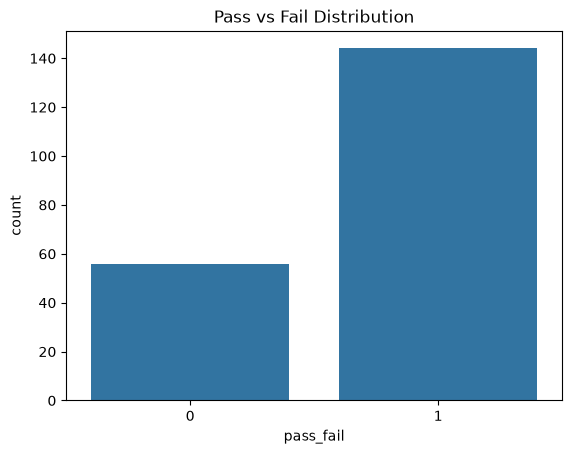

In [23]:
sns.countplot(data=df, x="pass_fail")
plt.title("Pass vs Fail Distribution")
plt.show()

### Numerical Features Distribution

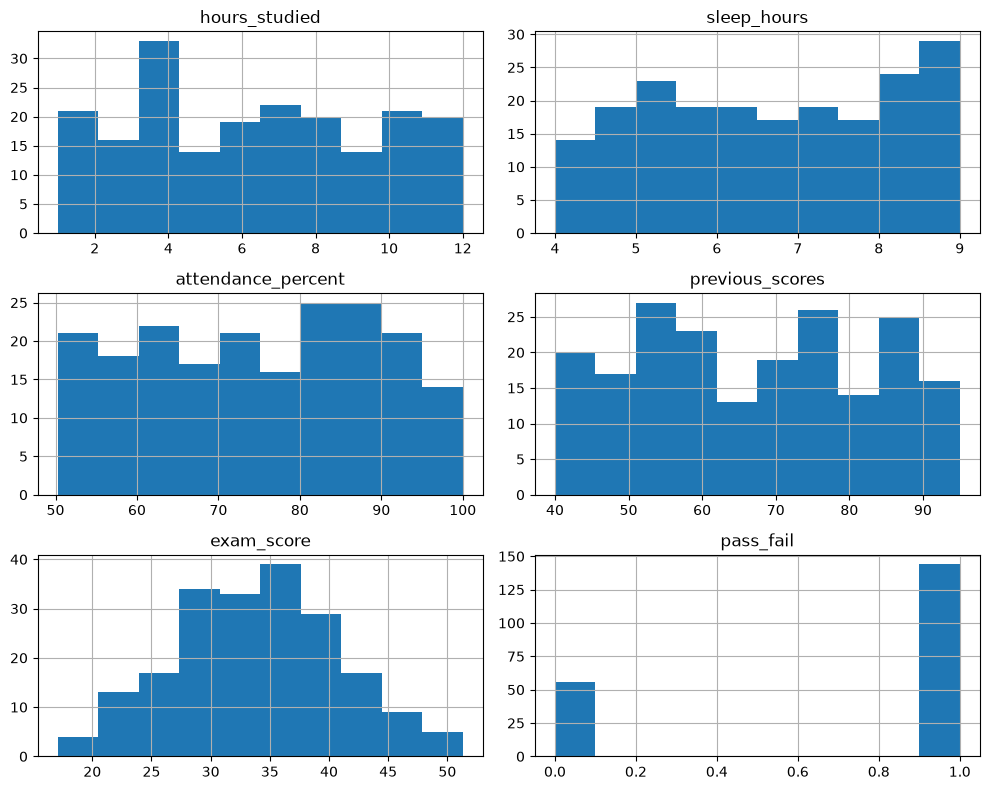

In [24]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

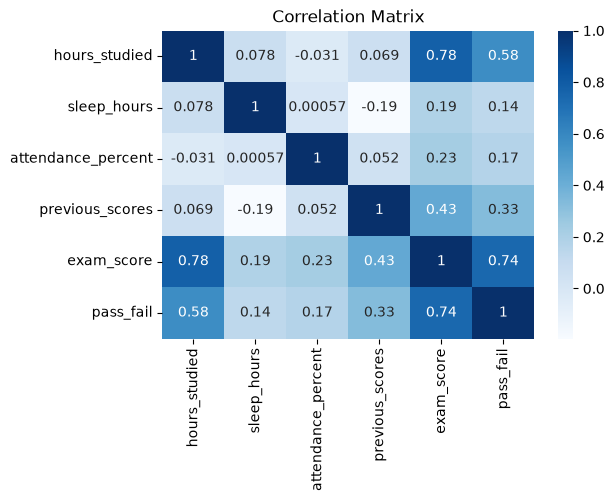

In [26]:
plt.figure(figsize=(6, 4))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")

plt.title("Correlation Matrix")
plt.show()

### 7.Feature Selection

In [27]:
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score', 'pass_fail'],
      dtype='str')

In [28]:
df.drop(columns=["student_id","exam_score"],inplace=True)

In [29]:
df.head(3)

,hours_studied,sleep_hours,attendance_percent,previous_scores,pass_fail
0,8.0,8.8,72.1,45,1
1,1.3,8.6,60.7,55,0
2,4.0,8.2,73.7,86,1


### 8.Define Features and Target

In [36]:
x = df.iloc[:,0:len(df.columns)-1]
y = df.iloc[:,-1]

In [38]:
x.head(3)

,hours_studied,sleep_hours,attendance_percent,previous_scores
0,8.0,8.8,72.1,45
1,1.3,8.6,60.7,55
2,4.0,8.2,73.7,86


In [39]:
y.head(3)

0    1
1    0
2    1
Name: pass_fail, dtype: int64

### 9.Train-Test Split

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=2,test_size=0.25)

In [ ]:
print("Training Features :", x_train.shape)
print("Testing Features  :", x_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (150, 4)
Testing Features  : (50, 4)
Training Labels   : (150,)
Testing Labels    : (50,)


### 10.Feature Scaling

In [64]:
# Standardize the numerical features before training the Logistic Regression model.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### 11.Build the Logistic Regression Model

In [65]:
from sklearn.linear_model import LogisticRegression

In [66]:
model = LogisticRegression(random_state=42)

In [67]:
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### 12.Make Predictions

In [68]:
y_pred = model.predict(x_test)

### 13.Evaluate the Model

In [69]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [70]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [79]:
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1:.2f}")

Accuracy : 0.78
Precision: 0.89
Recall   : 0.83
F1 Score : 0.86


### 14.Cross Validation

In [80]:
from sklearn.model_selection import cross_val_score

In [81]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

scores = cross_val_score(pipeline, x, y, cv=5)


In [82]:
print("Average Accuracy:", scores.mean())

Average Accuracy: 0.865


### 15.Save the Model

In [78]:
import joblib
joblib.dump(model, "../Model/logistic_regression_model.pkl")
joblib.dump(scaler, "../Model/scaler.pkl")

['../Model/scaler.pkl']